#  Procesamiento Digital de Imágenes - TP07: Nociones de segmentación

**Objetivos de la guía:**

* Comparar ventajas y desventajas de operadores de detección de bordes y su desempeño ante el ruido.

* Comprender el funcionamiento de la Transformada de Hough (TH) y su utilidad práctica.

* Introducir conceptos básicos de segmentación basada en regiones.

In [1]:
# Configuración Inicial

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown, RadioButtons
import ipywidgets as widgets

def mostrar_imagenes(imagenes, titulos, figsize=(15, 5)):
    n = len(imagenes)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1: axs = [axs]
    for i in range(n):
        img = imagenes[i]
        if len(img.shape) == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axs[i].set_title(titulos[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()

print("Entorno configurado. ¡Subí las imágenes ('patron_bordes.jpg', 'mosquito.jpg', 'letras1.tif', 'rosas.jpg', 'latas.png', etc.) al entorno de Colab!")


Entorno configurado. ¡Subí las imágenes ('patron_bordes.jpg', 'mosquito.jpg', 'letras1.tif', 'rosas.jpg', 'latas.png', etc.) al entorno de Colab!


## Ejercicio 1: Detección de bordes

Evaluaremos el desempeño de:
* Prewitt,
* Sobel,
* Laplaciano y
* Canny,

analizando el efecto de los parámetros y la robustez ante diferentes tipos de ruido.

In [2]:
def aplicar_prewitt(img):
    Kx_prewitt = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]], dtype=np.float32)
    Ky_prewitt = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]], dtype=np.float32)
    prewittx = cv2.filter2D(img, cv2.CV_64F, Kx_prewitt)
    prewitty = cv2.filter2D(img, cv2.CV_64F, Ky_prewitt)
    return cv2.magnitude(prewittx, prewitty)

def aplicar_sobel(img, dx, dy, ksize, bidireccional, ddepth=cv2.CV_64F):
    if bidireccional:
        sobelx = cv2.Sobel(img, ddepth, dx=1, dy=0, ksize=ksize)
        sobely = cv2.Sobel(img, ddepth, dx=0, dy=1, ksize=ksize)

        return cv2.magnitude(sobelx.astype(np.float64), sobely.astype(np.float64))
    else:
        return cv2.Sobel(img, ddepth, dx=dx, dy=dy, ksize=ksize)

def aplicar_laplaciano(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    return cv2.convertScaleAbs(laplacian)

def binarizar(img, umbral):
    img_abs = np.absolute(img)
    img_8u = cv2.normalize(img_abs, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, img_binaria = cv2.threshold(img_8u, umbral, 255, cv2.THRESH_BINARY)
    return img_binaria

In [3]:
def detector_bordes_completo(img_path, 
                              sobel_dtype_str, sobel_dx, sobel_dy, sobel_ksize, sobel_magnitud,
                              umbral_general, canny_th1, canny_th2, canny_l2):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # 1. Prewitt
    prewitt_mag = aplicar_prewitt(img)
    img_prewitt_bin = binarizar(prewitt_mag, umbral_general)

    # 2. sobel
    ddepth_sobel = cv2.CV_64F if "CV_64F" in sobel_dtype_str else cv2.CV_8U
    img_sobel = aplicar_sobel(
        img=img,
        ddepth=cv2.CV_64F if "CV_64F" in sobel_dtype_str else cv2.CV_8U,
        dx=sobel_dx,
        dy=sobel_dy,
        ksize=sobel_ksize,
        bidireccional=sobel_magnitud
    )
    img_sobel_bin = binarizar(img_sobel, umbral_general)

    # 3. Laplaciano
    laplacian_64f = cv2.Laplacian(img, cv2.CV_64F)
    img_laplacian_bin = binarizar(laplacian_64f, umbral_general)

    # 4. Canny
    img_canny_bin = cv2.Canny(img, canny_th1, canny_th2, L2gradient=canny_l2)

    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    plt.subplots_adjust(hspace=0.3, wspace=0.1)

    ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
    ax[0,1].imshow(img_prewitt_bin, cmap='gray'); ax[0,1].set_title(f"Prewitt (ksize 3)"); ax[0,1].axis('off')
    ax[0,2].imshow(img_laplacian_bin, cmap='gray'); ax[0,2].set_title(f"Laplaciano"); ax[0,2].axis('off')
    ax[1,0].imshow(img_canny_bin, cmap='gray'); ax[1,0].set_title(f"Canny \nTH1={canny_th1}, TH2={canny_th2}"); ax[1,0].axis('off')
    ax[1,1].imshow(img_sobel_bin, cmap='gray')
    ax[1,1].set_title(f"Sobel \ndx={sobel_dx}, dy={sobel_dy}, ksize={sobel_ksize}"); ax[1,1].axis('off')
    ax[1,2].axis('off')

    plt.show();

interact(
    detector_bordes_completo,
    img_path=Dropdown(options=['imagenes/patron_bordes.jpg', 'imagenes/mosquito.jpg'], value='imagenes/patron_bordes.jpg'),
    sobel_dtype_str=RadioButtons(options=['CV_8U', 'CV_64F'], value='CV_64F', description='Sobel:'),
    sobel_dx=IntSlider(min=0, max=2, value=1, description='Sob dx:'),
    sobel_dy=IntSlider(min=0, max=2, value=0, description='Sob dy:'),
    sobel_ksize=Dropdown(options=[('Scharr (-1)', -1), ('1x1', 1), ('3x3', 3), ('5x5', 5), ('7x7', 7)], value=3, description='Sobel KSize:'),
    sobel_magnitud=Checkbox(value=False, description='Mostrar Todos (dx + dy)'),
    umbral_general=IntSlider(min=0, max=255, value=70, description='Umbral:'),
    canny_th1=IntSlider(min=0, max=255, value=50, description='Canny TH1:'),
    canny_th2=IntSlider(min=0, max=255, value=150, description='Canny TH2:'),
    canny_l2=Checkbox(value=False, description='Canny L2 Gradient')
);

interactive(children=(Dropdown(description='img_path', options=('imagenes/patron_bordes.jpg', 'imagenes/mosqui…

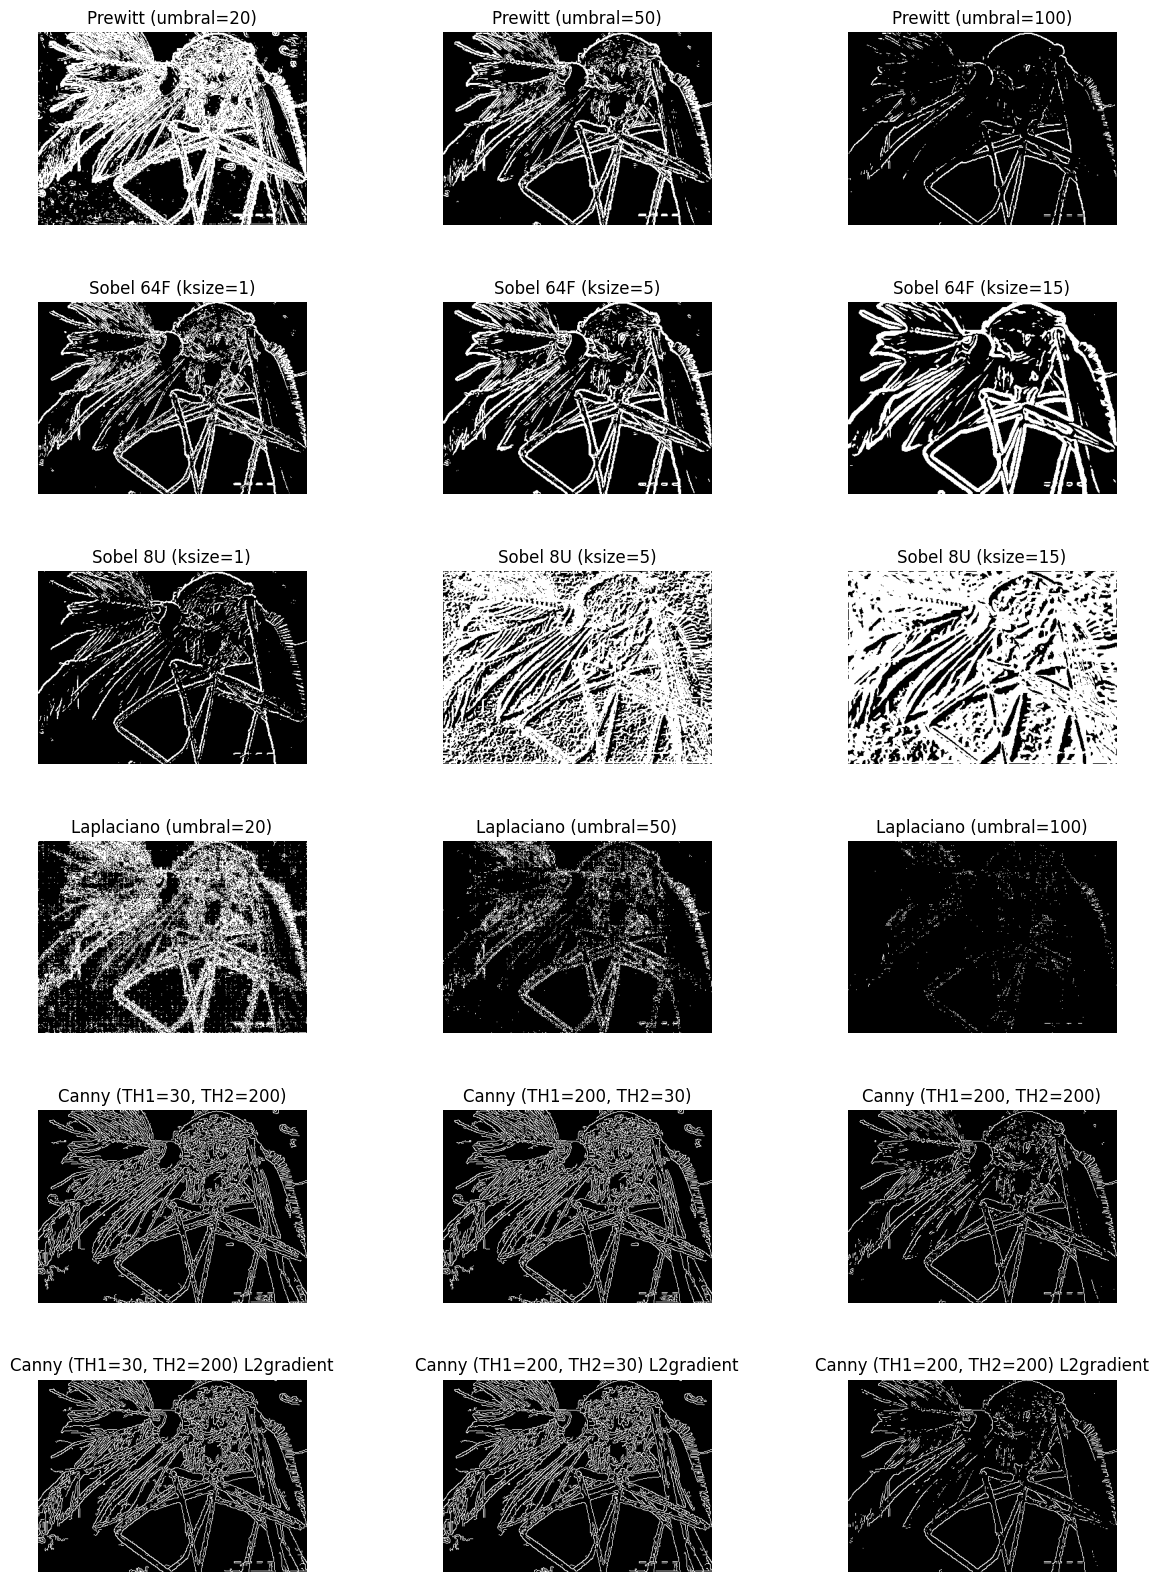

In [4]:
img = cv2.imread('imagenes/mosquito.jpg', cv2.IMREAD_GRAYSCALE)

# umbrales
u_bajo = 20
u_medio = 50
u_alto = 100

# kernels
ksize_bajo = 1
ksize_medio = 5
ksize_alto = 15

# Prewitt
prewitt_mag = aplicar_prewitt(img)
img_prewitt_1 = binarizar(prewitt_mag, u_bajo)
img_prewitt_2 = binarizar(prewitt_mag, u_medio)
img_prewitt_3 = binarizar(prewitt_mag, u_alto)

# Sobel
ddepth_sobel = cv2.CV_64F
sobel_1 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_1 = binarizar(sobel_1, u_medio)
sobel_2 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_medio, bidireccional=True)
img_sobel_2 = binarizar(sobel_2, u_medio)
sobel_3 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_alto, bidireccional=True)
img_sobel_3 = binarizar(sobel_3, u_medio)

ddepth_sobel = cv2.CV_8U
sobel_4 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_bajo, bidireccional=True)
img_sobel_4 = binarizar(sobel_4, u_medio)
sobel_5 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_medio, bidireccional=True)
img_sobel_5 = binarizar(sobel_5, u_medio)
sobel_6 = aplicar_sobel(img=img, ddepth=ddepth_sobel, dx=1, dy=1, ksize=ksize_alto, bidireccional=True)
img_sobel_6 = binarizar(sobel_6, u_medio)

# Laplaciano
laplacian = cv2.Laplacian(img, cv2.CV_64F)

img_laplacian_1 = binarizar(laplacian, u_bajo)
img_laplacian_2 = binarizar(laplacian, u_medio)
img_laplacian_3 = binarizar(laplacian, u_alto)

# Canny
# sin L2gradient
img_canny_1 = cv2.Canny(img, 30, 200, L2gradient=False)
img_canny_2 = cv2.Canny(img, 200, 30, L2gradient=False)
img_canny_3 = cv2.Canny(img, 200, 200, L2gradient=False)

# Con L2gradient
img_canny_4 = cv2.Canny(img, 30, 200, L2gradient=True)
img_canny_5 = cv2.Canny(img, 200, 30, L2gradient=True)
img_canny_6 = cv2.Canny(img, 200, 200, L2gradient=True)

fig, ax = plt.subplots(6, 3, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4, wspace=0.15)

ax[0,0].imshow(img_prewitt_1, cmap='gray'); ax[0,0].set_title(f"Prewitt (umbral={u_bajo})"); ax[0,0].axis('off')
ax[0,1].imshow(img_prewitt_2, cmap='gray'); ax[0,1].set_title(f"Prewitt (umbral={u_medio})"); ax[0,1].axis('off')
ax[0,2].imshow(img_prewitt_3, cmap='gray'); ax[0,2].set_title(f"Prewitt (umbral={u_alto})"); ax[0,2].axis('off')

ax[1,0].imshow(img_sobel_1, cmap='gray'); ax[1,0].set_title(f"Sobel 64F (ksize={ksize_bajo})"); ax[1,0].axis('off')
ax[1,1].imshow(img_sobel_2, cmap='gray'); ax[1,1].set_title(f"Sobel 64F (ksize={ksize_medio})"); ax[1,1].axis('off')
ax[1,2].imshow(img_sobel_3, cmap='gray'); ax[1,2].set_title(f"Sobel 64F (ksize={ksize_alto})"); ax[1,2].axis('off')

ax[2,0].imshow(img_sobel_4, cmap='gray'); ax[2,0].set_title(f"Sobel 8U (ksize={ksize_bajo})"); ax[2,0].axis('off')
ax[2,1].imshow(img_sobel_5, cmap='gray'); ax[2,1].set_title(f"Sobel 8U (ksize={ksize_medio})"); ax[2,1].axis('off')
ax[2,2].imshow(img_sobel_6, cmap='gray'); ax[2,2].set_title(f"Sobel 8U (ksize={ksize_alto})"); ax[2,2].axis('off')

ax[3,0].imshow(img_laplacian_1, cmap='gray'); ax[3,0].set_title(f"Laplaciano (umbral={u_bajo})"); ax[3,0].axis('off')
ax[3,1].imshow(img_laplacian_2, cmap='gray'); ax[3,1].set_title(f"Laplaciano (umbral={u_medio})"); ax[3,1].axis('off')
ax[3,2].imshow(img_laplacian_3, cmap='gray'); ax[3,2].set_title(f"Laplaciano (umbral={u_alto})"); ax[3,2].axis('off')

ax[4,0].imshow(img_canny_1, cmap='gray'); ax[4,0].set_title(f"Canny (TH1={30}, TH2={200})"); ax[4,0].axis('off')
ax[4,1].imshow(img_canny_2, cmap='gray'); ax[4,1].set_title(f"Canny (TH1={200}, TH2={30})"); ax[4,1].axis('off')
ax[4,2].imshow(img_canny_3, cmap='gray'); ax[4,2].set_title(f"Canny (TH1={200}, TH2={200})"); ax[4,2].axis('off')

ax[5,0].imshow(img_canny_4, cmap='gray'); ax[5,0].set_title(f"Canny (TH1={30}, TH2={200}) L2gradient"); ax[5,0].axis('off')
ax[5,1].imshow(img_canny_5, cmap='gray'); ax[5,1].set_title(f"Canny (TH1={200}, TH2={30}) L2gradient"); ax[5,1].axis('off')
ax[5,2].imshow(img_canny_6, cmap='gray'); ax[5,2].set_title(f"Canny (TH1={200}, TH2={200}) L2gradient"); ax[5,2].axis('off')

plt.show()

El laplaciano amplifica mucho el ruido, por lo que no sirve para ningun escenario de la imagen del mosquito, aunque funciona bien con la imagen artificial de patros de grises. Esto se debe a que busca los cruces por cero matemático con la segunda derivada, lo que la hace más sensible a cambios bruscos y aleatorios (como el ruido de alta frecuencia).

El pre-procesamiento interno que incorpora Canny es el suavizado gaussiano, lo cual limpia el ruido de alta frecuencia. Además, el umbral por histéresis da mayor control sobre la salida.

Todos los filtros fallan en cierta medida en zonas con textura compleja

##  Ejercicio 2: Transformada de Hough (TH)

Detectaremos puntos colineales y segmentos utilizando la Transformada de Hough Standard y Probabilística.

In [5]:
def dibujar_hough(img, threshold, color=(255, 0, 0), bordes=None):
    if bordes is None:
        bordes = cv2.Canny(img, 50, 150, apertureSize=3)

    img_hough = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLines(bordes, rho=1, theta=np.pi/180, threshold=threshold)
    for line in lines:
        rho, theta = line[0]

        # coordenadas polares a cartesianas
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        # lineas
        x1 = int(x0 + 10000 * (-b))
        y1 = int(y0 + 10000 * (a))
        x2 = int(x0 - 10000 * (-b))
        y2 = int(y0 - 10000 * (a))

        # Dibujamos la recta en la imagen (Color Azul en BGR)
        cv2.line(img_hough, (x1, y1), (x2, y2), color, 2)
    return img_hough

def dibujar_hough_probabilistico(img, threshold, minLineLength, maxLineGap, color=(255, 0, 0), bordes=None):
    img_hough_p = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    lines = cv2.HoughLinesP(bordes, rho=1, theta=np.pi/180, threshold=threshold, minLineLength=minLineLength, maxLineGap=maxLineGap)

    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Dibujamos el segmento acotado (Color Rojo en BGR)
        cv2.line(img_hough_p, (x1, y1), (x2, y2), color, 2)
    
    return img_hough_p

In [6]:
# Transformada de Hough Interactiva
def hough_interactivo(img_path, threshold, minLineLength, maxLineGap):
    img = cv2.imread(f"imagenes/{img_path}", cv2.IMREAD_GRAYSCALE)
    if img is None: return "Cargar imagen de prueba"

    # 1. Preprocesamiento: Detectar bordes primero (Obligatorio para Hough)
    bordes = cv2.Canny(img, 50, 150, apertureSize=3)

    # Hough standard
    img_hough = dibujar_hough(img, threshold, bordes=bordes)

    # Hough probabilistico
    img_hough_p = dibujar_hough_probabilistico(img, threshold, minLineLength, maxLineGap, bordes=bordes)

    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    ax[0].imshow(img, cmap='gray'); ax[0].set_title(f"Original"); ax[0].axis('off')
    ax[1].imshow(bordes, cmap='gray'); ax[1].set_title(f"Original"); ax[1].axis('off')
    ax[2].imshow(img_hough); ax[2].set_title(f"Hough Standard"); ax[2].axis('off')
    ax[3].imshow(img_hough_p); ax[3].set_title(f"Hough Probabilistico"); ax[3].axis('off');

interact(hough_interactivo,
         img_path=Dropdown(options=['building.jpg', 'letras1.tif', 'letras2.tif', 'snowman.png'], value='building.jpg'),
         threshold=IntSlider(min=10, max=300, value=100),
         minLineLength=IntSlider(min=1, max=200, value=50),
         maxLineGap=IntSlider(min=1, max=50, value=10));


interactive(children=(Dropdown(description='img_path', options=('building.jpg', 'letras1.tif', 'letras2.tif', …

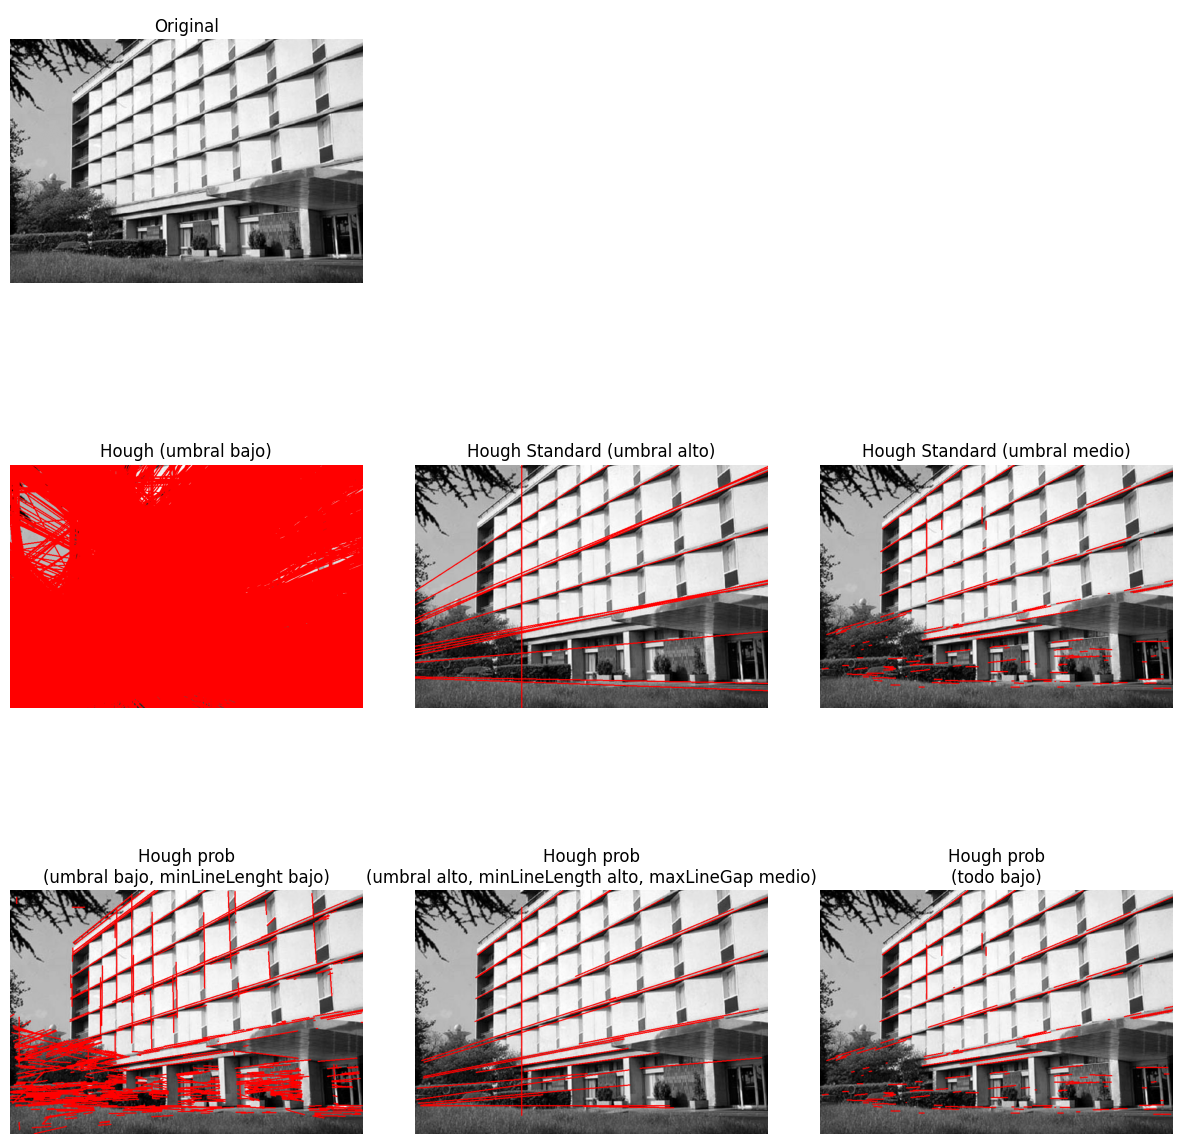

In [7]:
img = cv2.imread(f"imagenes/building.jpg", cv2.IMREAD_GRAYSCALE)
bordes = cv2.Canny(img, 50, 150, apertureSize=3)

# Hough standard
img_hough1 = dibujar_hough(img, threshold=130, bordes=bordes)
img_hough2 = dibujar_hough(img, threshold=250, bordes=bordes)
img_hough3 = dibujar_hough(img, threshold=190, bordes=bordes)

# Hough probabilistico
img_hough_p1 = dibujar_hough_probabilistico(img, threshold=130, minLineLength=1, maxLineGap=10, bordes=bordes)
img_hough_p2 = dibujar_hough_probabilistico(img, threshold=225, minLineLength=185, maxLineGap=25, bordes=bordes)
img_hough_p3 = dibujar_hough_probabilistico(img, threshold=205, minLineLength=1, maxLineGap=5, bordes=bordes)

fig, ax = plt.subplots(3, 3, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.15)

ax[0,0].imshow(img, cmap='gray'); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].imshow(img_hough1, cmap='gray'); ax[1,0].set_title(f"Hough (umbral bajo)"); ax[1,0].axis('off')
ax[1,1].imshow(img_hough2); ax[1,1].set_title(f"Hough Standard (umbral alto)"); ax[1,1].axis('off')
ax[1,2].imshow(img_hough_p3); ax[1,2].set_title(f"Hough Standard (umbral medio)"); ax[1,2].axis('off');
ax[2,0].imshow(img_hough_p1, cmap='gray'); ax[2,0].set_title(f"Hough prob\n(umbral bajo, minLineLenght bajo)"); ax[2,0].axis('off')
ax[2,1].imshow(img_hough_p2); ax[2,1].set_title(f"Hough prob\n(umbral alto, minLineLength alto, maxLineGap medio)"); ax[2,1].axis('off')
ax[2,2].imshow(img_hough_p3); ax[2,2].set_title(f"Hough prob\n(todo bajo)"); ax[2,2].axis('off');

Un punto aislado en el espacio está representado en $(\rho, \theta)$ por una sinusoidal.

En el caso de un umbral bajo y, en el caso del probabilistico, una longitud minima de linea bajo, cualquier contorno califica como línea. En este caso el gap máximo entre lineas pasa a ser casi irrelevante ya que no "filtrará" los **falsos positivos**.

Aunque es más tolerante al ruido, el problema de hough estándar es que no distingue del comienzo y el final de una linea (solo da angulo y distancia), por lo que es mejor el método probabilístico para objetos reales, sobretodo por el control en el espacio máximo entre una linea y otra colineal.

El problema del probabilístico es que puede perder líneas si la muestra de puntos no es suficientemente grande, pero a cambio es computacionalmente menos costoso.

El hough estándar es útil para buscar ejes "globales" sin importar mucho los límites físicos (una línea de horizonte o puntos de fuga).

El hough probabilístico es útil para casos en los que se necesite delimitar objetos reales, por ejemplo si se necesitara medir su tamaño. Tambíen puede ser necesario en caso de que la latencia sea un factor limitante.

##  Ejercicio 3: Segmentación mediante crecimiento de regiones

Implementaremos un algoritmo de **Region Growing** que se expande desde una semilla (**seed**) evaluando la homogeneidad de los píxeles vecinos.

In [8]:
def mascara_crecimiento(img, semillax, semillay, tolerancia):
    h, w = img.shape
    # Matriz para marcar los píxeles visitados/segmentados
    mascara = np.zeros_like(img)
    visitados = np.zeros_like(img, dtype=bool)

    # Valor del píxel semilla
    valor_semilla = int(img[semillay, semillax])

    # pila inicial con la semilla
    pila = [(semillax, semillay)]
    visitados[semillay, semillax] = True

    # vecinos: derecha, izquierda, abajo, arriba
    vecindario = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    # crecimiento
    while pila:
        # sacar de pila
        cx, cy = pila.pop()

        # marcar
        mascara[cy, cx] = 255

        # vecinos
        for dx, dy in vecindario:
            nx, ny = cx + dx, cy + dy

            # bordes de la imagen
            if 0 <= nx < w and 0 <= ny < h:
                if not visitados[ny, nx]:
                    # tolerancia
                    if abs(int(img[ny, nx]) - valor_semilla) <= tolerancia:
                        visitados[ny, nx] = True
                        pila.append((nx, ny))

    return mascara
    

In [9]:
# Crecimiento de Regiones

img = cv2.imread('imagenes/medica.png', cv2.IMREAD_GRAYSCALE)
def crecimiento_regiones(x_seed, y_seed, tolerancia):
    # Matriz para marcar los píxeles visitados/segmentados
    mascara = mascara_crecimiento(img, x_seed, y_seed, tolerancia)

    # dibujar semilla
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.circle(img_color, (x_seed, y_seed), 3, (0, 0, 255), -1)

    mostrar_imagenes([img_color, mascara], ["Original con Semilla", f"Segmentación (Tol={tolerancia})"]);

# Sliders para interactuar con la posición de la semilla y la tolerancia
interact(crecimiento_regiones,
         x_seed=IntSlider(min=0, max=img.shape[1], value=128),
         y_seed=IntSlider(min=0, max=img.shape[0], value=128),
         tolerancia=IntSlider(min=1, max=50, value=10));


interactive(children=(IntSlider(value=128, description='x_seed', max=468), IntSlider(value=128, description='y…

(np.float64(-0.5), np.float64(467.5), np.float64(262.5), np.float64(-0.5))

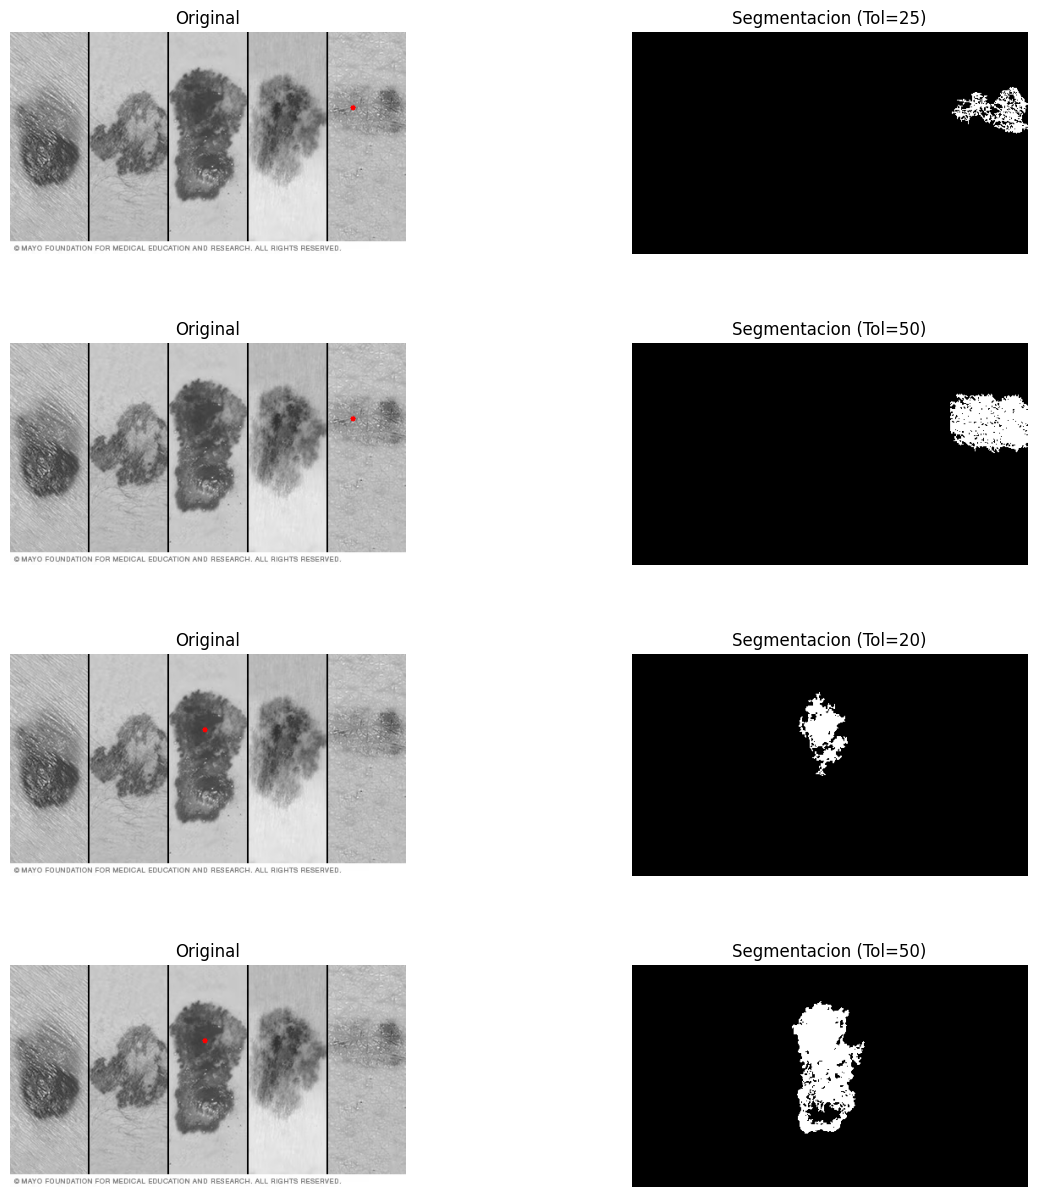

In [10]:
mascara1 = mascara_crecimiento(img, 405, 90, 25)
img_color1 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(img_color1, (405, 90), 3, (255, 0, 0), -1)

mascara2 = mascara_crecimiento(img, 405, 90, 50)
img_color2 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(img_color2, (405, 90), 3, (255, 0, 0), -1)

mascara3 = mascara_crecimiento(img, 230, 90, 20)
img_color3 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(img_color3, (230, 90), 3, (255, 0, 0), -1)

mascara4 = mascara_crecimiento(img, 230, 90, 50)
img_color4 = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(img_color4, (230, 90), 3, (255, 0, 0), -1)

fig, ax = plt.subplots(4, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.15)

ax[0,0].imshow(img_color1, cmap='gray'); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
ax[0,1].imshow(mascara1, cmap='gray'); ax[0,1].set_title(f"Segmentacion (Tol={25})"); ax[0,1].axis('off')

ax[1,0].imshow(img_color2, cmap='gray'); ax[1,0].set_title(f"Original"); ax[1,0].axis('off')
ax[1,1].imshow(mascara2, cmap='gray'); ax[1,1].set_title(f"Segmentacion (Tol={50})"); ax[1,1].axis('off')

ax[2,0].imshow(img_color4, cmap='gray'); ax[2,0].set_title(f"Original"); ax[2,0].axis('off')
ax[2,1].imshow(mascara3, cmap='gray'); ax[2,1].set_title(f"Segmentacion (Tol={20})"); ax[2,1].axis('off')

ax[3,0].imshow(img_color3, cmap='gray'); ax[3,0].set_title(f"Original"); ax[3,0].axis('off')
ax[3,1].imshow(mascara4, cmap='gray'); ax[3,1].set_title(f"Segmentacion (Tol={50})"); ax[3,1].axis('off')

Se usaron imagenes de melanomas.

En imágenes médicas puede suceder que partes totalmente distintas se encuentren en el mismo rango de grises. Por ejemplo, un tumor y otros tejidos pueden encontrarse en el mismo rango de grises, por lo que se pintarían de igual forma. Con el crecimiento se puede aisla el tumor.

##  Ejercicio 4: Segmentación en color y etiquetado (Componentes Conectadas)

Automatizaremos el conteo de rosas en la imagen **rosas.jpg** extrayendo regiones y descartando el ruido.

* Puede investigar con que funciones de OpenCV puede obtener más información de las regiones, por ejemplo: tamaño de las regiones, tamaño promedio, cantidad de regiones bajo y sobre la media, tasa de circularidad, etc: **cv.connectedComponentsWithStats, cv.minEnclosingCircle(), cv.minAreaRect()**, etc.

---

* Nota: para descartar el ruido puede hacerlo usando filtros de medias y procesos ad-hoc como ya lo vimos previamente. O bien, puede usar **cv2.erode, cv2.dilate, cv2.morphologyEx** (apertura o cierre) para limpiar manchas sueltas. Ésto lo veremos en detalle en la unidad de morfología pero puede ver simplemente la forma de uso de estas operaciones y usarlas aquí.

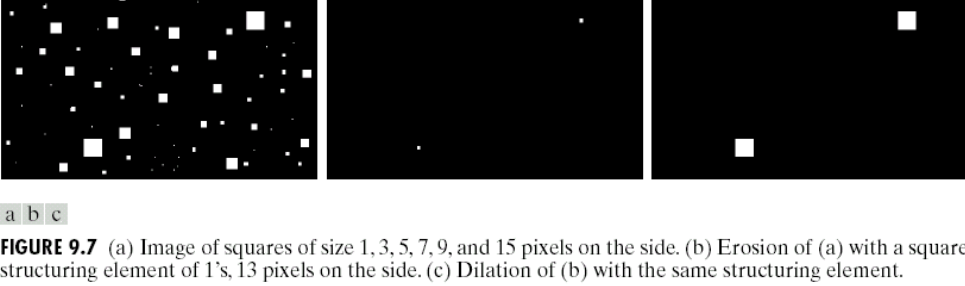

In [11]:
#Componentes Conectadas
def contar_rosas(umbral_area_minima):
    img = cv2.imread('imagenes/rosas.jpg')
    # 1. Segmentación por color (Similar al TP04)
    # en hsv el rojo pega la vuelta, esto es equivalente a H[165:10]
    rojo_bajo1 = np.array([0, 70, 50])
    rojo_alto1 = np.array([10, 255, 255])
    rojo_bajo2 = np.array([165, 70, 50])
    rojo_alto2 = np.array([180, 255, 255])
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mascara1 = cv2.inRange(hsv, rojo_bajo1, rojo_alto1)
    mascara2 = cv2.inRange(hsv, rojo_bajo2, rojo_alto2)
    # sumamos mascaras
    mascara = cv2.bitwise_or(mascara1, mascara2)

    # 2. Mejorar la máscara (Descartar ruido morfológico)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_limpia = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara_limpia = cv2.morphologyEx(mascara_limpia, cv2.MORPH_CLOSE, kernel)

    # 3. Etiquetado de componentes conectadas
    retval, labels, stats, centroids = cv2.connectedComponentsWithStats(mascara_limpia)

    # 4. Filtrar y contar rosas automáticas (descartando regiones muy chicas)
    cant_rosas = 0
    for i in range(1, retval): # Empezamos en 1 para ignorar el fondo (etiqueta 0)
        area = stats[i, cv2.CC_STAT_AREA]
        if area > umbral_area_minima:
            cant_rosas += 1
            cx, cy = int(centroids[i][0]), int(centroids[i][1])
            cv2.circle(img, (cx, cy), 10, (0, 255, 0), -1) # Dibujar centro

    print(f"Cantidad de rosas detectadas: {cant_rosas}")

    mostrar_imagenes([img, mascara, mascara_limpia],
                     ["Conteo Automático", "Mascara", "Máscara Limpia"]);

interact(contar_rosas,
         umbral_area_minima=IntSlider(min=0, max=300, step=25, value=25),
);


interactive(children=(IntSlider(value=25, description='umbral_area_minima', max=300, step=25), Output()), _dom…

Cantidad de rosas detectadas: 18


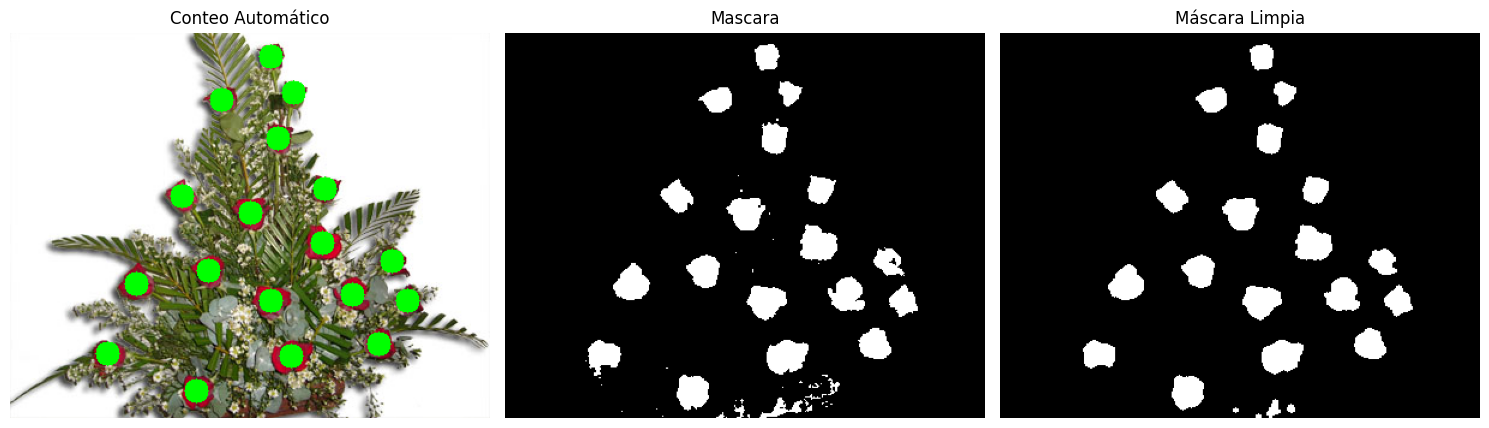

Cantidad de rosas detectadas: 20


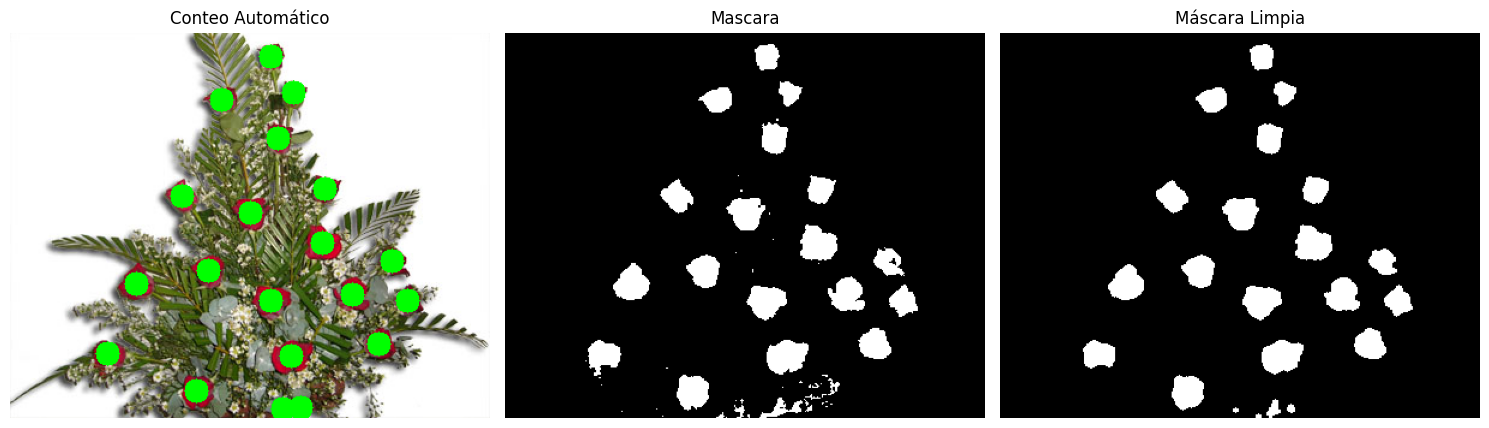

In [12]:
contar_rosas(umbral_area_minima=250)
contar_rosas(umbral_area_minima=25)

Si se hubieran dejado las manchas producto del umbralizado, el etiquetado podría haber arrojado falsos positivos si muchas de esas manchas hubieran estado conectadas de forma que superaran la tolerancia.

La principal diferencia entre este algoritmo y el anterior de crecicimento es que en este caso no estamos guiándolo dandole una semilla, sino que escanea toda la imagen.

**Reflexiona sobre lo que observas:**

* Antes de aplicar el etiquetado de componentes conectadas (**connectedComponents**), fue necesario aplicar un filtrado morfológico (limpieza de ruido). ¿Qué habría ocurrido con el recuento automático (retval) si hubiéramos dejado pequeñas manchas de ruido aisladas en la máscara binaria?

* ¿En qué se diferencia fundamentalmente la lógica de búsqueda de las "Componentes conectadas" frente al algoritmo de "Crecimiento de regiones" implementado en el ejercicio anterior?


##  Ejercicio 5: Aplicaciones Prácticas

Utilizaremos la transformada de Hough circular para discriminar objetos (ejemplo: latas de pie en una toma desde arriba) y Hough de líneas para encontrar pistas de aterrizaje.

---

Tenga en cuenta que el método debe ser útil para imágenes de otros aeropuertos, con caracterı́sticas similares pero con variaciones en la localización, el largo de la pista, la inclinación de la pista, etc.

Para probar la robustez de su código, se le sugiere que genere imágenes rotadas y/o desplazadas de las propuestas.

In [13]:
#  Conteo y discriminación de Latas (Hough Circles)

def detectar_latas(minDist, param1, param2, minRadius, maxRadius, r_threshold):
    img = cv2.imread('imagenes/latas.png')
    if img is None: return "Cargar 'latas.png'"

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Preprocesamiento recomendado para HoughCircles
    img_blur = cv2.medianBlur(img_gris, 5)

    # Configurar cv2.HoughCircles
    img_hough_c = cv2.cvtColor(img_blur, cv2.COLOR_GRAY2BGR)

    # Param2: Acumulador (menor = más círculos falsos). minDist: distancia mínima entre centros.
    circulos = cv2.HoughCircles(
        img_blur,
        method=cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=minDist,
        param1=param1,
        param2=param2,
        minRadius=minRadius,
        maxRadius=maxRadius
    )

    # al menos un circulo
    chicas = 0
    grandes = 0
    if circulos is not None:
        # redondeamos
        circulos = np.uint16(np.around(circulos))
        for circle in circulos[0]:
            cx, cy, r = circle
            if r < r_threshold:
                chicas += 1
                color = (0,0,255)
            else:
                grandes += 1
                color = (0,255,0)
            cv2.circle(img_hough_c, (cx, cy), r, color, 2)

    print(f"Total: {chicas+grandes} | Grandes: {grandes} | Chicas: {chicas}")
    mostrar_imagenes([img, img_hough_c], ["Fuente", "Detección de latas"])

interact(
    detectar_latas,
    minDist=IntSlider(min=1, max=300, value=10),
    param1=IntSlider(min=1, max=300, value=10),
    param2=IntSlider(min=1, max=300, value=10),
    minRadius=IntSlider(min=1, max=300, value=10),
    maxRadius=IntSlider(min=1, max=300, value=10),
    r_threshold=IntSlider(min=1, max=300, value=10)
);


interactive(children=(IntSlider(value=10, description='minDist', max=300, min=1), IntSlider(value=10, descript…

Total: 11 | Grandes: 5 | Chicas: 6


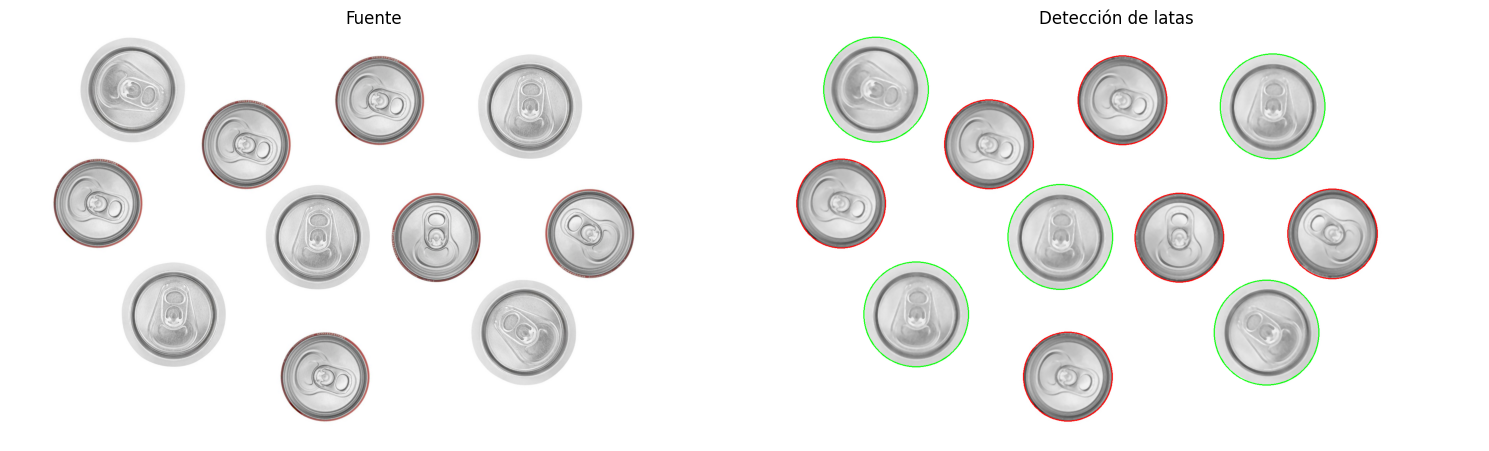

In [14]:
detectar_latas(minDist=249, param1=1, param2=73, minRadius=116, maxRadius=140, r_threshold=135)

In [15]:
def aplicar_filtro_media_alfa_recortado(img, ksize=3, d=8):
    img_f = np.zeros(img.shape)

    # padding
    padsize = (ksize-1)//2
    im_p = cv2.copyMakeBorder(np.copy(img), *[padsize]*4, cv2.BORDER_CONSTANT,0).astype(np.float64)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            S = np.sort(im_p[i:i+ksize,j:j+ksize].flatten())
            S = S[d//2:S.shape[0]-d//2]
            img_f[i, j] = np.sum(S)/S.shape[0]

    return np.uint8(img_f)

In [ ]:
#Segmentación de Pistas de Aeropuerto

def detectar_pista_aeropuerto(img_path='imagenes/corrientes_ruidogris.jpg', canny_th1=10, canny_th2=10, threshold=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return f"Cargar {img_path}"

    # 1. Preprocesamiento (Eliminar ruido gaussiano e impulsivo)
    # el alfa recortado hace 2x1
    img_limpia = aplicar_filtro_media_alfa_recortado(img, ksize=3, d=8)

    # 2. Detección de Bordes (Canny)
    bordes = cv2.Canny(img_limpia, canny_th1, canny_th2, L2gradient=True)

    # 3. Transformada de Hough (Líneas)
    img_hough = dibujar_hough(img_limpia, threshold=threshold, bordes=bordes)

    mostrar_imagenes([img, img_limpia, bordes, img_hough], ["Pista Principal", "Imagen limpia", "Bordes", "Pista detectada"]);

interact(
    detectar_pista_aeropuerto,
    canny_th1=IntSlider(min=1, max=300, value=200),
    canny_th2=IntSlider(min=1, max=300, value=200),
    threshold=IntSlider(min=1, max=300, value=250),
);

interactive(children=(Text(value='imagenes/corrientes_ruidogris.jpg', description='img_path'), IntSlider(value…

In [ ]:
detectar_pista_aeropuerto(canny_th1=200, canny_th2=200, threshold=170)

Los falsos positivos que pueden aparecer corresponden a bordes de distintas latas que pueden interpretarse como un circulo entre las dos.

En las imagenes de aeropuertos, la clave para diferenciar la pista de las calles aledañas está en el umbral que se elige. Ojo que pare fotos donde existen calles aledañas más largas que la propia pista de aterrisaje (y que sean rectas), esto no funcionará.